In [1]:
#basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# stats
from scipy.stats import chisquare
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import dunnett
from statsmodels.stats.proportion import proportion_confint

#others
import math
import os
from pathlib import Path
from IPython.display import HTML, display
import ipywidgets as widgets
import pickle
import gc


In [2]:
import sys
sys.path.append("src")   # VERY IMPORTANT

In [3]:
BASE_DIR = Path.cwd()
data_path1 = os.path.join(BASE_DIR, 'data','upworthy-archive-confirmatory-packages-03.12.2020.csv')
data_path2 = os.path.join(BASE_DIR, 'data','upworthy-archive-exploratory-packages-03.12.2020.csv')
data_path3 = os.path.join(BASE_DIR, 'data','upworthy-archive-holdout-packages-03.12.2020.csv')
data_path4 = os.path.join(BASE_DIR, 'data','upworthy-archive-undeployed-packages.01.12.2021.csv')

In [4]:
BASE_DIR

PosixPath('/home/d/Documents/Other_projects/Headline_Engagement_Analysis')

In [5]:
df_confirmatory=pd.read_csv(data_path1)
df_exploratory=pd.read_csv(data_path2)
df_holdout=pd.read_csv(data_path3)
df_undeployed=pd.read_csv(data_path4)

/tmp/ipykernel_1437706/1820728600.py:1: DtypeWarning: Columns (0: square) have mixed types. Specify dtype option on import or set low_memory=False.
  df_confirmatory=pd.read_csv(data_path1)
/tmp/ipykernel_1437706/1820728600.py:4: DtypeWarning: Columns (0: square) have mixed types. Specify dtype option on import or set low_memory=False.
  df_undeployed=pd.read_csv(data_path4)


In [6]:
#df_confirmatory=pd.read_csv("upworthy-archive-confirmatory-packages-03.12.2020.csv")
#df_exploratory=pd.read_csv("upworthy-archive-exploratory-packages-03.12.2020.csv")
#df_holdout=pd.read_csv("upworthy-archive-holdout-packages-03.12.2020.csv")
#df_undeployed=pd.read_csv("upworthy-archive-undeployed-packages.01.12.2021.csv")

In [7]:
df_confirmatory.head()

,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,11,2014-11-20 11:33:26.475,2016-04-02 16:25:54.046,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,"Let’s See … Hire Cops, Pay Teachers, Buy Books...",<p>Iff you start with the basic fact that inno...,let-s-see-hire-cops-pay-teachers-buy-books-for...,546dce659ad54ec65b000041,3118,8,0.1,False,False,NaN,NaN,201446
1,12,2014-11-20 15:00:01.032,2016-04-02 16:25:54.128,546e01d626714c6c4400004e,Things that matter. Pass 'em on.,People Sent This Lesbian Questions And Her Rai...,<p>I'll be honest. I've wondered about 7.</p>,people-sent-this-lesbian-questions-and-her-rai...,546d1b4bfd3617f091000041,4587,130,55.8,False,False,NaN,NaN,201446
2,13,2014-11-20 11:33:51.973,2016-04-02 16:25:54.069,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,$3 Million Is What It Takes For A State To Leg...,<p>Iff you start with the basic fact that inno...,3-million-is-what-it-takes-for-a-state-to-lega...,546dce659ad54ec65b000041,3017,19,26.9,False,False,NaN,NaN,201446
3,14,2014-11-20 11:34:12.107,2016-04-02 16:25:54.049,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,The Fact That Sometimes Innocent People Are Ex...,<p>Iff you start with the basic fact that inno...,the-fact-that-sometimes-innocent-people-are-ex...,546dce659ad54ec65b000041,2974,26,100.0,True,False,NaN,NaN,201446
4,15,2014-11-20 11:34:33.935,2016-04-02 16:25:54.072,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,Reason #351 To End The Death Penalty: It Costs...,<p>Iff you start with the basic fact that inno...,reason-351-to-end-the-death-penalty-it-costs-3...,546dce659ad54ec65b000041,3050,10,0.2,False,False,NaN,NaN,201446


In [8]:
# join all df togeher
df_all = pd.concat([df_confirmatory, df_exploratory, df_holdout, df_undeployed],
    keys=["confirmatory", "exploratory", "holdout", "undeployed"]
     ).reset_index(level=0).rename(columns={"level_0": "dataset_id"}).reset_index(drop=True)
# delete _id
df_all = df_all.drop("_id", axis=1)
df_all

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,confirmatory,11.0,2014-11-20 11:33:26.475,2016-04-02 16:25:54.046,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,"Let’s See … Hire Cops, Pay Teachers, Buy Books...",<p>Iff you start with the basic fact that inno...,let-s-see-hire-cops-pay-teachers-buy-books-for...,546dce659ad54ec65b000041,3118.0,8.0,0.1,False,False,NaN,NaN,201446.0
1,confirmatory,12.0,2014-11-20 15:00:01.032,2016-04-02 16:25:54.128,546e01d626714c6c4400004e,Things that matter. Pass 'em on.,People Sent This Lesbian Questions And Her Rai...,<p>I'll be honest. I've wondered about 7.</p>,people-sent-this-lesbian-questions-and-her-rai...,546d1b4bfd3617f091000041,4587.0,130.0,55.8,False,False,NaN,NaN,201446.0
2,confirmatory,13.0,2014-11-20 11:33:51.973,2016-04-02 16:25:54.069,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,$3 Million Is What It Takes For A State To Leg...,<p>Iff you start with the basic fact that inno...,3-million-is-what-it-takes-for-a-state-to-lega...,546dce659ad54ec65b000041,3017.0,19.0,26.9,False,False,NaN,NaN,201446.0
3,confirmatory,14.0,2014-11-20 11:34:12.107,2016-04-02 16:25:54.049,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,The Fact That Sometimes Innocent People Are Ex...,<p>Iff you start with the basic fact that inno...,the-fact-that-sometimes-innocent-people-are-ex...,546dce659ad54ec65b000041,2974.0,26.0,100.0,True,False,NaN,NaN,201446.0
4,confirmatory,15.0,2014-11-20 11:34:33.935,2016-04-02 16:25:54.072,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,Reason #351 To End The Death Penalty: It Costs...,<p>Iff you start with the basic fact that inno...,reason-351-to-end-the-death-penalty-it-costs-3...,546dce659ad54ec65b000041,3050.0,10.0,0.2,False,False,NaN,NaN,201446.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229044,undeployed,NaN,2014-11-20 03:48:54.29,2016-04-02 16:31:40.693,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b49545240e55400005d,0.0,0.0,0.0,False,False,NaN,NaN,NaN
229045,undeployed,NaN,2014-11-20 03:50:04.032,2016-04-02 16:31:40.696,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b4bfd3617f091000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN
229046,undeployed,NaN,2014-11-20 03:50:51.753,2016-04-02 16:25:53.976,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8fd36177d3300004b,0.0,0.0,0.0,False,False,NaN,NaN,NaN
229047,undeployed,NaN,2014-11-20 03:51:04.482,2016-04-02 16:25:53.979,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8badeb52b15000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN


# Data Description
* **upworthy-archive-confirmatory-packages-03.12.2020.csv** — confirmatory experiments designed to validate prior findings
* **upworthy-archive-exploratory-packages-03.12.2020.csv** — exploratory experiments designed to generate hypotheses
* **upworthy-archive-holdout-packages-03.12.2020.csv** — holdout data for validation and robustness checks
* **upworthy-archive-undeployed-packages-01.12.2021.csv** — experiments that were not deployed to production

Each database have several experiments. An experiment is the **clickability_test_id** and an arm (what is been tested in the experiment) is the **eyecatcher_id**. For each experiment we are testing different eyecatcher_id. So it is a A/B/n test

Each dataset includes fields such as:

* **headline** — text of the tested headline
* **impressions** — number of times the headline was shown
* **clicks** — number of times the headline was clicked
* **eyecatcher_id** — ID for images used in experiments
* **clickability_test_id**— experiment identifier

### Questions than can be Investigated

1. Do headlines containing numbers perform better than those without?
2. Does framing a headline as a question increase engagement?
3. Are shorter headlines more effective than longer ones?
4. Can you analyis every single experiment

### Practicalities 
Analyze the provided data and provide insights using appropriate statistical methods, including:

* Two-proportion z-tests for comparing CTR between groups
* Chi-square tests for categorical comparisons
* Exploratory vs confirmatory replication checks
  
Make sure the solution includes:

* Clear data exploration steps
* Properly explained statistical methodology
* Concise interpretations of results for business stakeholders
* The focus is not only on producing results but also on showing the reasoning and methodology behind A/B testing and its role in decision-making

# Preprocessing

In [9]:
df_confirmatory.info()

<class 'pandas.DataFrame'>
RangeIndex: 105551 entries, 0 to 105550
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            105551 non-null  int64  
 1   created_at            105551 non-null  str    
 2   updated_at            105551 non-null  str    
 3   clickability_test_id  105551 non-null  str    
 4   excerpt               94335 non-null   str    
 5   headline              105551 non-null  str    
 6   lede                  105485 non-null  str    
 7   slug                  105551 non-null  str    
 8   eyecatcher_id         105420 non-null  str    
 9   impressions           105551 non-null  int64  
 10  clicks                105551 non-null  int64  
 11  significance          105551 non-null  float64
 12  first_place           105551 non-null  bool   
 13  winner                105551 non-null  bool   
 14  share_text            14632 non-null   str    
 15  square     

In [10]:
#df_list=[df_confirmatory,df_exploratory,df_holdout,df_undeployed]

In [11]:
# change databs
#date_format = "%Y-%m-%d %H:%M:%S.%f"

df_all["created_at"] = pd.to_datetime(df_all["created_at"], format="mixed")
df_all["updated_at"] = pd.to_datetime(df_all["updated_at"], format="mixed")

In [12]:
df_all["CTR"]=df_all["clicks"]/df_all["impressions"]

In [13]:
df_all

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week,CTR
0,confirmatory,11.0,2014-11-20 11:33:26.475,2016-04-02 16:25:54.046,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,"Let’s See … Hire Cops, Pay Teachers, Buy Books...",<p>Iff you start with the basic fact that inno...,let-s-see-hire-cops-pay-teachers-buy-books-for...,546dce659ad54ec65b000041,3118.0,8.0,0.1,False,False,NaN,NaN,201446.0,0.002566
1,confirmatory,12.0,2014-11-20 15:00:01.032,2016-04-02 16:25:54.128,546e01d626714c6c4400004e,Things that matter. Pass 'em on.,People Sent This Lesbian Questions And Her Rai...,<p>I'll be honest. I've wondered about 7.</p>,people-sent-this-lesbian-questions-and-her-rai...,546d1b4bfd3617f091000041,4587.0,130.0,55.8,False,False,NaN,NaN,201446.0,0.028341
2,confirmatory,13.0,2014-11-20 11:33:51.973,2016-04-02 16:25:54.069,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,$3 Million Is What It Takes For A State To Leg...,<p>Iff you start with the basic fact that inno...,3-million-is-what-it-takes-for-a-state-to-lega...,546dce659ad54ec65b000041,3017.0,19.0,26.9,False,False,NaN,NaN,201446.0,0.006298
3,confirmatory,14.0,2014-11-20 11:34:12.107,2016-04-02 16:25:54.049,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,The Fact That Sometimes Innocent People Are Ex...,<p>Iff you start with the basic fact that inno...,the-fact-that-sometimes-innocent-people-are-ex...,546dce659ad54ec65b000041,2974.0,26.0,100.0,True,False,NaN,NaN,201446.0,0.008742
4,confirmatory,15.0,2014-11-20 11:34:33.935,2016-04-02 16:25:54.072,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,Reason #351 To End The Death Penalty: It Costs...,<p>Iff you start with the basic fact that inno...,reason-351-to-end-the-death-penalty-it-costs-3...,546dce659ad54ec65b000041,3050.0,10.0,0.2,False,False,NaN,NaN,201446.0,0.003279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229044,undeployed,NaN,2014-11-20 03:48:54.290,2016-04-02 16:31:40.693,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b49545240e55400005d,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN
229045,undeployed,NaN,2014-11-20 03:50:04.032,2016-04-02 16:31:40.696,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b4bfd3617f091000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN
229046,undeployed,NaN,2014-11-20 03:50:51.753,2016-04-02 16:25:53.976,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8fd36177d3300004b,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN
229047,undeployed,NaN,2014-11-20 03:51:04.482,2016-04-02 16:25:53.979,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8badeb52b15000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN


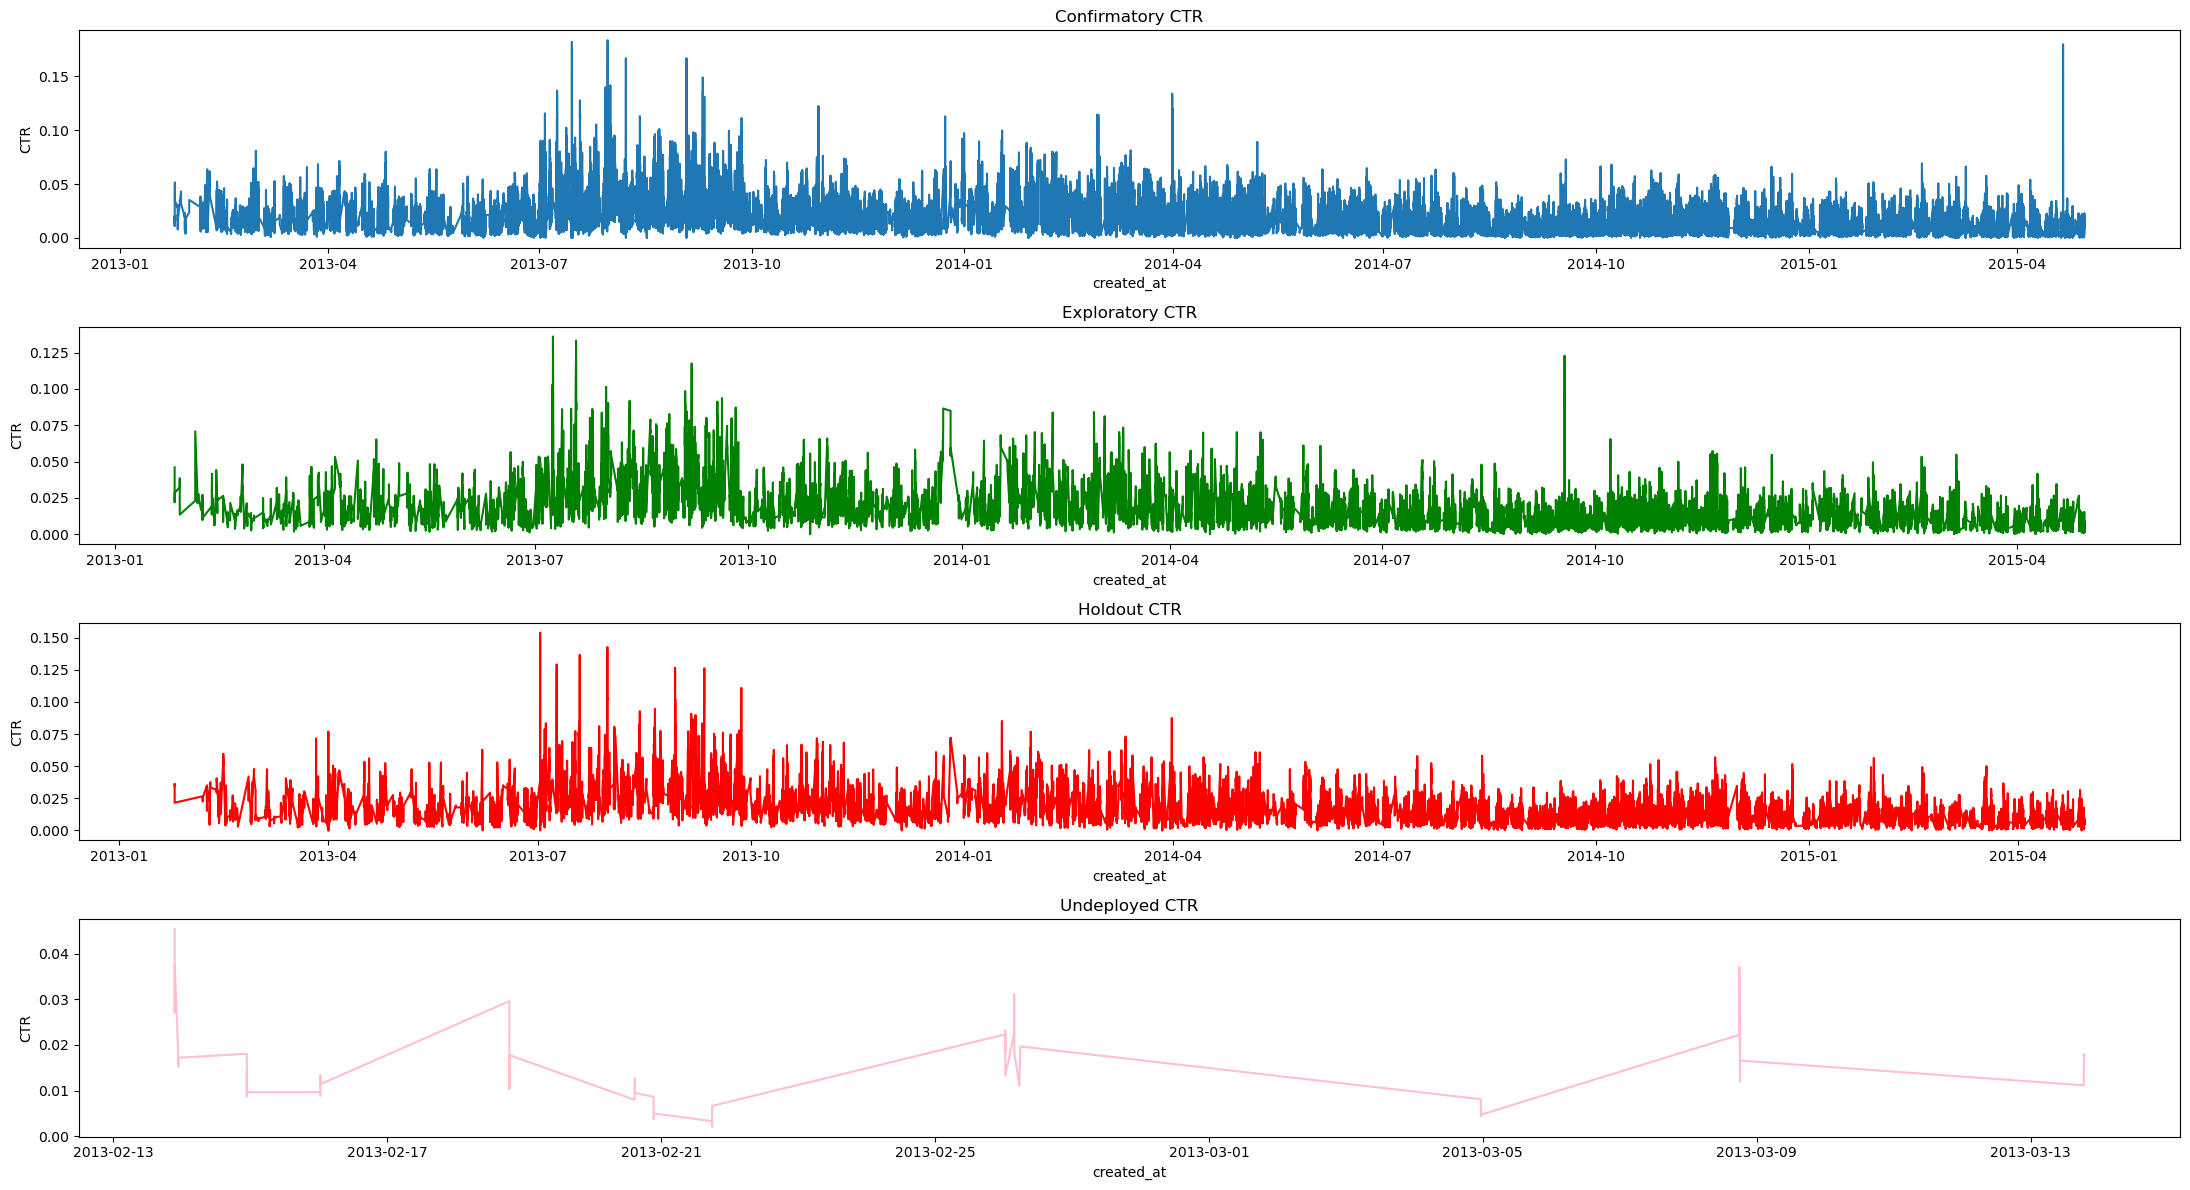

In [14]:
#plt.figure(figsize=(20, 4))
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(22, 12))
sns.lineplot(data=df_all[df_all["dataset_id"]=="confirmatory"], x="created_at", y="CTR", ax=ax1)
sns.lineplot(data=df_all[df_all["dataset_id"]=="exploratory"], x="created_at", y="CTR", ax=ax2, color="green")
sns.lineplot(data=df_all[df_all["dataset_id"]=="holdout"], x="created_at", y="CTR", ax=ax3, color="red")
sns.lineplot(data=df_all[df_all["dataset_id"]=="undeployed"], x="created_at", y="CTR", ax=ax4, color="pink")


ax1.set_title("Confirmatory CTR")
ax2.set_title("Exploratory CTR")
ax3.set_title("Holdout CTR")
ax4.set_title("Undeployed CTR")


plt.tight_layout()
plt.show()

* There seems to be an issue around 2013-07 to 2013-10
* There are some spike in the data. Not sure what to do with it

In [15]:
# summary of data 
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0               78232
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  21127
 headline                     9
 lede                     58171
 slug                         0
 eyecatcher_id              182
 impressions              54211
 clicks                   54211
 significance                 0
 first_place                  0
 winner                       0
 share_text              189266
 square                  178893
 test_week                78232
 CTR                      78175
 dtype: int64,
 229049)

In [16]:
# Filters the DataFrame to show only the duplicate rows
duplicate_rows = df_all[df_all.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [dataset_id, Unnamed: 0, created_at, updated_at, clickability_test_id, excerpt, headline, lede, slug, eyecatcher_id, impressions, clicks, significance, first_place, winner, share_text, square, test_week, CTR]
Index: []


In [17]:
# delete empty eyecatcher_id
df_all.dropna(subset=['eyecatcher_id'],inplace=True)
# delete empty headline
df_all.dropna(subset=['headline'],inplace=True)
# delele rows with empty impressions
df_all.dropna(subset=['impressions'],inplace=True)
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0               24020
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  17217
 headline                     0
 lede                      6258
 slug                         0
 eyecatcher_id                0
 impressions                  0
 clicks                       0
 significance                 0
 first_place                  0
 winner                       0
 share_text              146299
 square                  124681
 test_week                24020
 CTR                      23963
 dtype: int64,
 174655)

In [18]:
# delete all zeros for impressions
df_all = df_all[df_all['impressions'] != 0]
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0                  57
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  16027
 headline                     0
 lede                       104
 slug                         0
 eyecatcher_id                0
 impressions                  0
 clicks                       0
 significance                 0
 first_place                  0
 winner                       0
 share_text              129792
 square                  101017
 test_week                   57
 CTR                          0
 dtype: int64,
 150692)

In [19]:
# remove dates btw 2013-June and 2013-Oct
df_all = df_all[~((df_all["created_at"] >= "2013-06-25") &(df_all["created_at"] <= "2013-10-01"))]
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0                  57
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  14128
 headline                     0
 lede                       103
 slug                         0
 eyecatcher_id                0
 impressions                  0
 clicks                       0
 significance                 0
 first_place                  0
 winner                       0
 share_text              114689
 square                  101017
 test_week                   57
 CTR                          0
 dtype: int64,
 135589)

In [20]:
# fix number of clicks when it is zero. Haldane-Anscombe Correction
# not needed for Bayesian statistics

# Create a mask for rows where clicks are 0
zero_clicks_mask = df_all['clicks'] == 0

#Add 0.5 to the clicks column for those rows
df_all.loc[zero_clicks_mask, 'clicks'] += 0.5

#Add 1.0 to impressions for those rows to balance the success/failure ratio
if 'impressions' in df_all.columns:
    df_all.loc[zero_clicks_mask, 'impressions'] += 1.0

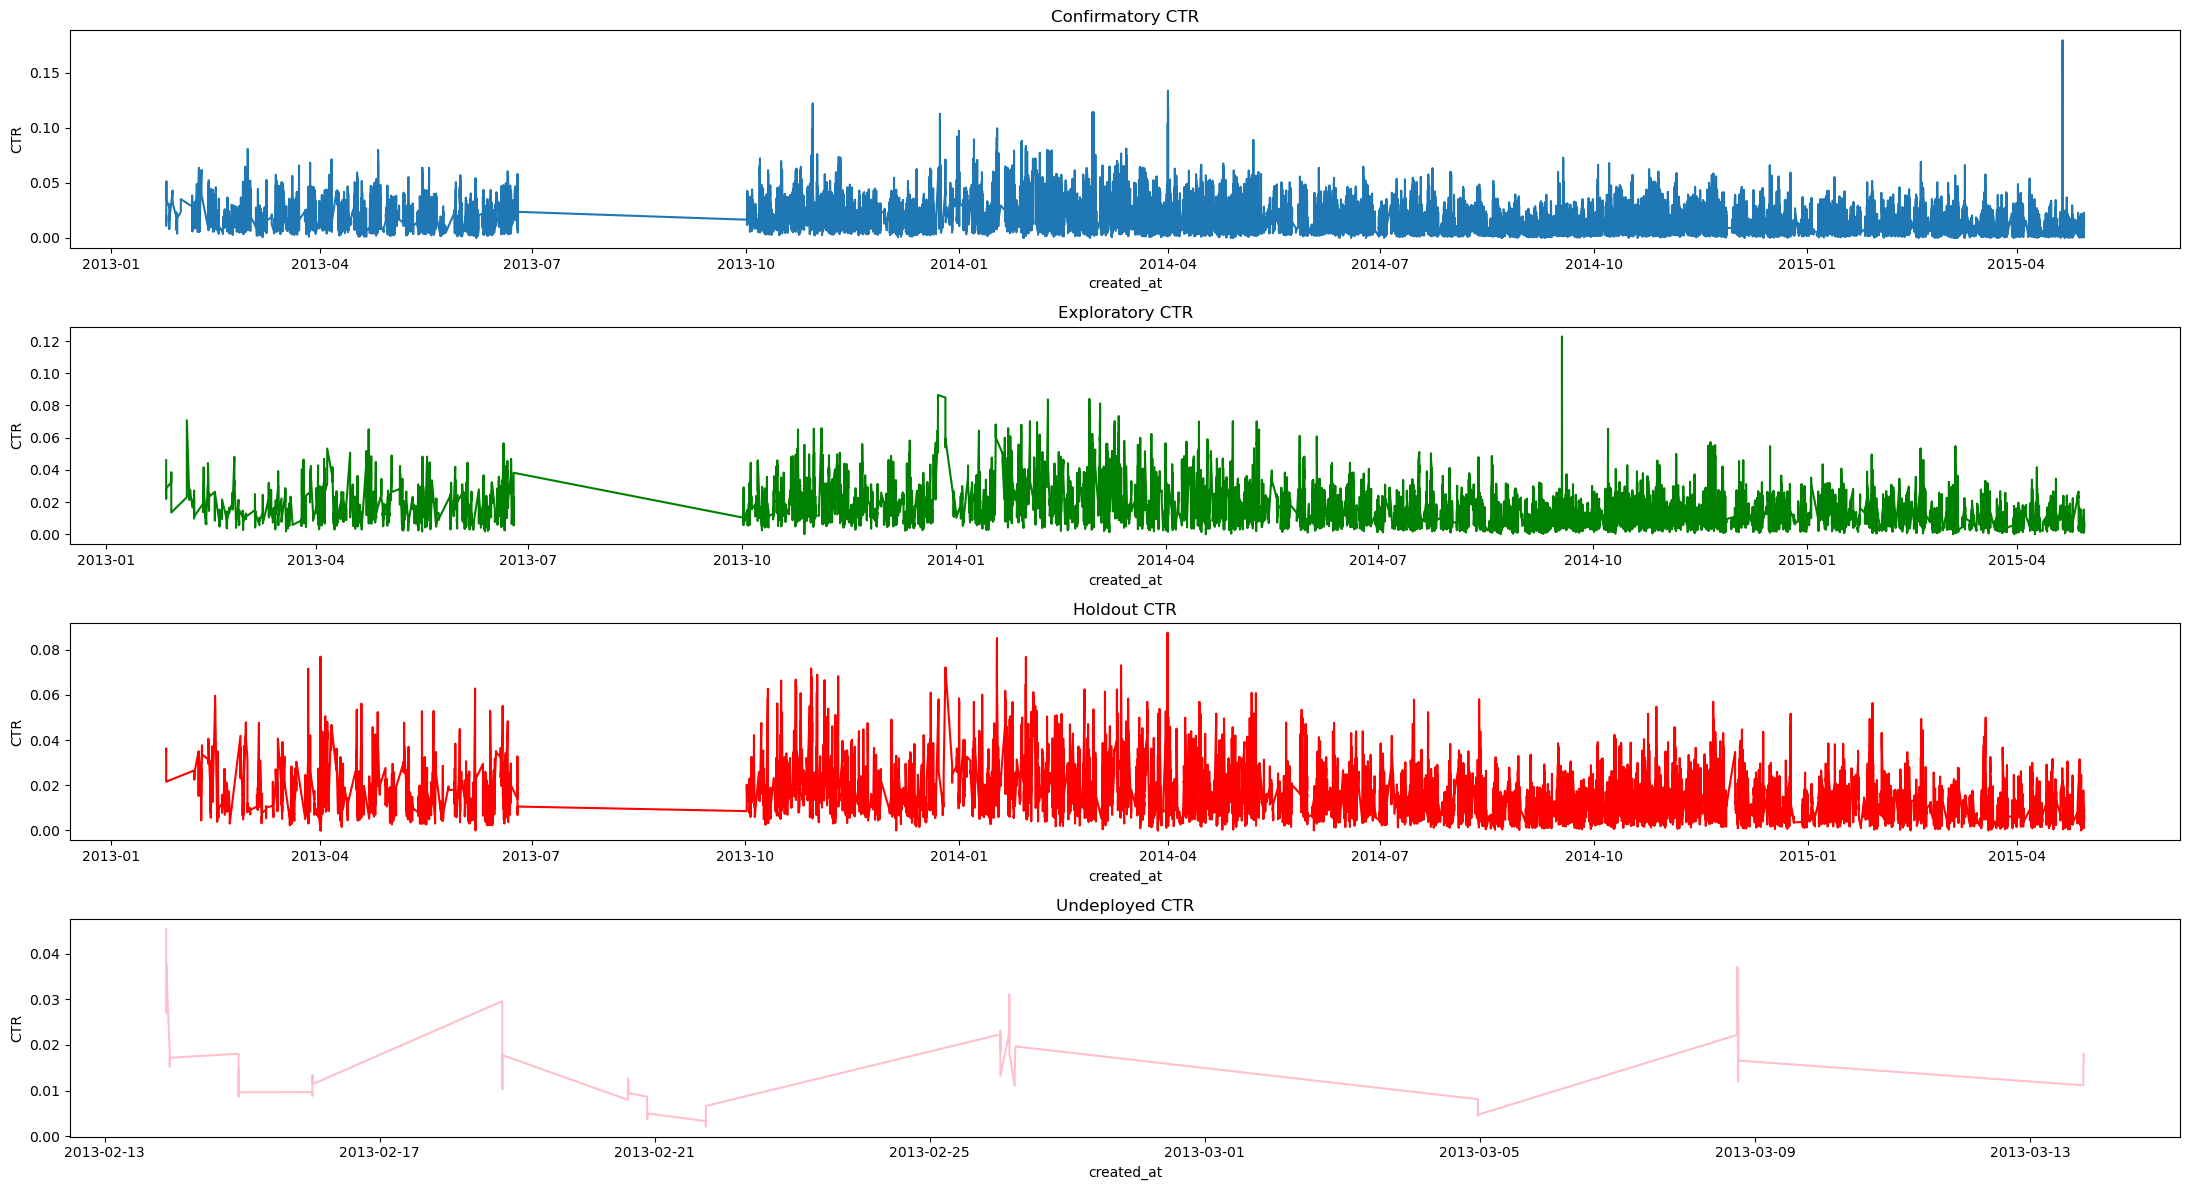

In [21]:
#plot again
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(22, 12))
sns.lineplot(data=df_all[df_all["dataset_id"]=="confirmatory"], x="created_at", y="CTR", ax=ax1)
sns.lineplot(data=df_all[df_all["dataset_id"]=="exploratory"], x="created_at", y="CTR", ax=ax2, color="green")
sns.lineplot(data=df_all[df_all["dataset_id"]=="holdout"], x="created_at", y="CTR", ax=ax3, color="red")
sns.lineplot(data=df_all[df_all["dataset_id"]=="undeployed"], x="created_at", y="CTR", ax=ax4, color="pink")


ax1.set_title("Confirmatory CTR")
ax2.set_title("Exploratory CTR")
ax3.set_title("Holdout CTR")
ax4.set_title("Undeployed CTR")


plt.tight_layout()
plt.show()

In [21]:
# count number of words/ or numbers in the headline

df_all["word_count_headline"] = (df_all["headline"].str.findall(r"[a-zA-Z]+").str.len().fillna(0).astype(int))
df_all["num_count_headline"] = (df_all["headline"].str.findall(r"\d+").str.len().fillna(0).astype(int))
df_all["word_num_count_headline"] =  df_all["word_count_headline"]+  df_all["num_count_headline"]

In [22]:
# check if headline has a question mark?
#df_all["any_questions"] = df_all["headline"].astype(str).str.contains(r"\?").astype(int)
# check if headline has any number 
#df_all["any_number"] = 0
#df_all.loc[df_all["num_count_headline"] > 0, "any_number"] = 1

In [23]:
# check if headline has a question mark?
df_all["any_questions"] = df_all["headline"].astype(str).str.contains(r"\?").astype(int)
# check if headline has any number 
df_all["any_number"] = 0
df_all.loc[df_all["num_count_headline"] > 0, "any_number"] = 1

# Part 2: Multi experiment dive for confirmatory test
Over here I am going to be analyzing all the experiments, tabulate the results and then see what other characteristics that define whether a arm is good or not

In [24]:
# make a list of unique clickability_test_id
#df_confirmatory=df_all[df_all["dataset_id"]=="confirmatory"]
conf_click_list=df_all["clickability_test_id"].unique()

df_filtered = df_all[df_all["clickability_test_id"].isin(conf_click_list)]
eyecatcher_counts = df_filtered.groupby("clickability_test_id")["eyecatcher_id"].nunique(dropna=False)

# 2. Filter for counts > 1. You want an experiment to be at least 2 variant/arm
filtered_counts = eyecatcher_counts[eyecatcher_counts > 1]

# 3. Convert the Series index and values into a list of tuples
clic_test_eyecatcher_gt_1_all = list(filtered_counts.items())
#clic_test_eyecatcher_gt_1=clic_test_eyecatcher_gt_1[:10]

In [25]:
len(clic_test_eyecatcher_gt_1_all)

9988

In [26]:
######################################



##########################################

import os
import gc

# --- CRITICAL FIX 1: FORCE HEADLESS BACKEND ---
# This MUST happen BEFORE importing pyplot or running any helper functions
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
import pandas as pd

# --- Configuration ---
alpha = 0.05
output_dir = "traffic_share_plots"
os.makedirs(output_dir, exist_ok=True)

output_html_path = "styled_master_dashboard.html"
chunk_size = 500
total_items = len(clic_test_eyecatcher_gt_1_all)

# ---  1: Write HTML Head and CSS Styling to File ---
html_header = """<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Master Analytics Dashboard</title>
    <style>
        body { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; margin: 20px; background: #f9f9f9; }
        .dashboard-table { border-collapse: collapse; width: 100%; background: #ffffff; box-shadow: 0 1px 3px rgba(0,0,0,0.1); font-size: 13px; }
        .dashboard-table th { background-color: #f2f2f2; color: #333; font-weight: bold; padding: 10px; border: 1px solid #ddd; text-align: left; }
        .dashboard-table td { padding: 8px; border: 1px solid #ddd; vertical-align: top; }
        .dashboard-table tr:nth-child(even) { background-color: #f9f9f9; }
        .dashboard-table tr:hover { background-color: #f1f5f9; }
        .dataframe { border-collapse: collapse; font-size: 11px; width: 100%; }
        .dataframe th, .dataframe td { padding: 4px; border: 1px solid #ccc; text-align: left; }
        .dataframe th { background-color: #eaeaea; }
    </style>
</head>
<body>
    <h2>Master Analysis Report</h2>
    <table class="dashboard-table">
        <thead>
            <tr>
                <th>num_variant</th><th>num_eyecatcher</th><th>dataset_id</th><th>exp_id</th>
                <th>traffic_share</th><th>chi2_stat</th><th>chi2_p_value</th><th>chi2_decision</th>
                <th>max_relative_lift_vs_control</th><th>max_cohens_h_vs_control_eff_size</th>
                <th>power_plot</th><th>Is any variant Significant</th><th>CI_plot</th><th>dunnett_details</th>
            </tr>
        </thead>
        <tbody>
"""

with open(output_html_path, "w", encoding="utf-8") as f:
    f.write(html_header)

print(f"Initialized headless dashboard file. Processing {total_items} items in chunks of {chunk_size}...")

# --- 2: Main Processing & Streaming Loop ---
for chunk_start in range(0, total_items, chunk_size):
    chunk = clic_test_eyecatcher_gt_1_all[chunk_start : chunk_start + chunk_size]
    print(f"Processing chunk {chunk_start // chunk_size + 1}...")

    chunk_html_buffer = []

    for tup in chunk:
        test_id = tup[0]
        
        # Free previous df memory immediately by reusing the variable context
        df = df_all[df_all["clickability_test_id"] == test_id].copy()
        if df.empty:
            continue

        num_variant = len(df)
        unique_eyecatcher = df["eyecatcher_id"].nunique()
        dataset_id = df["dataset_id"].iloc[0]

        # 3. Traffic share
        df.loc[:, "traffic_share"] = df["impressions"] / df["impressions"].sum()
        from helper_functions import traffic_plot
        traffic_share_val = traffic_plot(df, test_id)

        # 4. Chi-square test
        from helper_functions import chi_square
        chi_sq_res = chi_square(df, alpha)  
        chi2_decision, chi2_stat, chi2_p_value = chi_sq_res[0], chi_sq_res[1], chi_sq_res[2]

        # 5. Effect size
        from helper_functions import relative_lift_cohen_d
        df_big = relative_lift_cohen_d(df)
        df = df_big[0]  
        max_lift = df_big[1]
        max_cohen = df_big[2]

        # 6. Power plot
        from helper_functions import power_plot
        power_plot_val = power_plot(df, alpha, test_id)

        # 7. Dunnett Hypothesis test
        alpha_significant_str = f"Significant (α={alpha})?"
        from helper_functions import Dunnett_Hypothesis_test
        hypo_result_df = Dunnett_Hypothesis_test(df, alpha, alpha_significant_str)

        yes_no = "YES" if (hypo_result_df[alpha_significant_str] == "YES").any() else "NO"

        # 8. Confidence Interval Plot
        from helper_functions import confidence_interval_plot
        ci_plot_val = confidence_interval_plot(hypo_result_df, alpha, alpha_significant_str, test_id)
        
        # Strict ordered teardown of matplotlib objects
        plt.cla()  # Clear current axes
        plt.clf()  # Clear current figure
        plt.close('all')

        # Sub-table Dropdown Logic
        df_html = hypo_result_df.to_html(classes='dataframe', index=True)
        dropdown_html = f"""
        <details style="padding: 4px;">
            <summary style="font-weight: bold; cursor: pointer; color: #0066cc; min-width: 150px;">
                ▶ View Dunnett Table
            </summary>
            <div style="margin-top: 8px; overflow-x: auto; max-height: 250px; border: 1px solid #ddd; padding: 5px;">
                {df_html}
            </div>
        </details>
        """

        # Formatted Row Strings
        row_html = f"""
        <tr>
            <td>{num_variant}</td>
            <td>{unique_eyecatcher}</td>
            <td>{dataset_id}</td>
            <td>{test_id}</td>
            <td>{traffic_share_val}</td>
            <td>{chi2_stat:.3g}</td>
            <td>{chi2_p_value:.3g}</td>
            <td>{chi2_decision}</td>
            <td>{max_lift}</td>
            <td>{max_cohen}</td>
            <td>{power_plot_val}</td>
            <td>{yes_no}</td>
            <td>{ci_plot_val}</td>
            <td>{dropdown_html}</td>
        </tr>
        """
        chunk_html_buffer.append(row_html)

    # Flush chunk to disk
    if chunk_html_buffer:
        with open(output_html_path, "a", encoding="utf-8") as f:
            f.writelines(chunk_html_buffer)

   # empty chunk and other dataframes
    chunk_html_buffer = None
    df = None
    hypo_result_df = None
    df_big = None
    
    gc.collect()

# --- Close HTML Elements ---
with open(output_html_path, "a", encoding="utf-8") as f:
    f.write("\n        </tbody>\n    </table>\n</body>\n</html>")

print(f"\nSuccess! Open '{output_html_path}'.")


Initialized headless dashboard file. Processing 9988 items in chunks of 500...
Processing chunk 1...
Skipping power plot for 51591d04581fbb0002004ebd: Control CTR is 0 or invalid.
Processing chunk 2...
Skipping power plot for 51b1483db03b2c754b006448: Control CTR is 0 or invalid.
Skipping power plot for 51b148c40e8f501965005f1a: Control CTR is 0 or invalid.


/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/scipy/stats/_multicomp.py:428: RuntimeWarning: invalid value encountered in divide
  return z / std, std, mean_control, mean_samples


Processing chunk 3...
Processing chunk 4...
Skipping power plot for 529fa059980d6d23770003a8: Control CTR is 0 or invalid.
Processing chunk 5...
Skipping power plot for 52e7c72d5a5c7ce8ae000014: Control CTR is 0 or invalid.
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Skipping power plot for 538c79dd945967fc50000006: Control CTR is 0 or invalid.
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Skipping power plot for 53f7538b15ec7de635000007: Control CTR is 0 or invalid.
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Skipping power plot for 54f7a74c3737320019040000: Control CTR is 0 or invalid.
Processing chunk 20...
Skipping power plot for 550c67da3862650018510000: Control CTR is 0 or invalid.
Skipping power plot for 550c6b42636661000c5f0000: Control CTR is 0 or invalid.
Skipping power plot for 5519b63337383600